# Exploratory Data Analysis — High-Frequency Book Data

**Source**: `processed/train.parquet` (output of `split_and_save`)

**Columns**: `stock_id`, `time_id`, `seconds_in_bucket`, `wap`, `bid_ask_spread`, `total_volume`, `price_spread`, `depth_imbalance`

**Goal**: Understand the raw data before feature engineering — distributions, cross-stock variation, noise characteristics, and the relationship between input features and the target (log RV over seconds 480–599).

---

In [35]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.stats import gaussian_kde, pearsonr, spearmanr
import warnings
warnings.filterwarnings('ignore')


plt.rcParams.update({
    'figure.dpi': 120,
    'axes.titlesize': 12,
    'axes.labelsize': 11,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'legend.fontsize': 9,
    'figure.facecolor': 'white',
})

# ── Paths ──
_HERE = Path.cwd() if '__file__' not in globals() else Path(__file__).resolve().parent
PROJECT_ROOT = _HERE if (_HERE / 'processed').exists() else _HERE.parent
RAW_PATH = "C:\\Users\\ngdo0466\\Downloads\\full.parquet"
OUTPUT_DIR = PROJECT_ROOT / 'models'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# ── Constants ──
TARGET_START = 480
TARGET_END   = 600
INPUT_END    = 480
RV_FLOOR     = 1e-4
LOG_RV_FLOOR = np.log(RV_FLOOR)

FEATURE_COLS = ['wap', 'bid_ask_spread', 'total_volume', 'price_spread', 'depth_imbalance']

print(f'Source: {RAW_PATH}')


Source: C:\Users\ngdo0466\Downloads\full.parquet


## 1. Load Data & Basic Shape

In [31]:
def parse_stock_id(s):
    s = str(s)
    return int(s.replace('stock_', '')) if 'stock_' in s else int(s)

print('Loading data ...')
df = pd.read_parquet(RAW_PATH,  engine="fastparquet")
df['stock_id'] = df['stock_id'].apply(parse_stock_id)

print(f'Shape: {df.shape}')
print(f'Stocks: {df["stock_id"].nunique()}')
print(f'Time IDs: {df["time_id"].nunique()}')
print(f'Seconds range: {df["seconds_in_bucket"].min()} – {df["seconds_in_bucket"].max()}')
print(f'\nColumns: {list(df.columns)}')
print(f'\nDtypes:\n{df.dtypes}')
print(f'\nMemory: {df.memory_usage(deep=True).sum() / 1e9:.2f} GB')
df.head(10)

Loading data ...


MemoryError: Unable to allocate 3.83 GiB for an array with shape (2, 257359200) and data type int64

In [ ]:
# Missing values
print('Missing values per column:')
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(3)
pd.DataFrame({'count': missing, 'pct': missing_pct}).query('count > 0')

Missing values per column:


,count,pct


In [ ]:
# Rows per (stock_id, time_id) — how many seconds per sample?
rows_per_sample = df.groupby(['stock_id', 'time_id']).size()
print(f'Rows per (stock, time_id):')
print(rows_per_sample.describe())
print(f'\nAll samples have exactly 600 rows? {(rows_per_sample == 600).all()}')
if not (rows_per_sample == 600).all():
    print(f'  min: {rows_per_sample.min()}, max: {rows_per_sample.max()}')
    print(f'  samples with < 600 rows: {(rows_per_sample < 600).sum()}')

Rows per (stock, time_id):
count    428932.0
mean        600.0
std           0.0
min         600.0
25%         600.0
50%         600.0
75%         600.0
max         600.0
dtype: float64

All samples have exactly 600 rows? True


## 2. Feature Distributions (Global)

In [ ]:
# Descriptive stats
df[FEATURE_COLS].describe(percentiles=[.01, .05, .25, .5, .75, .95, .99]).T

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
wap,257359200.0,1.000007,0.003690,0.883063,0.989269,0.995174,0.998752,1.000017,1.001264,1.004792,1.010983,1.127077e+00
bid_ask_spread,257359200.0,0.000663,0.000766,0.000003,0.000050,0.000115,0.000242,0.000426,0.000807,0.001939,0.003646,5.017002e-02
total_volume,257359200.0,3424.286599,20439.204321,4.000000,35.000000,131.000000,338.000000,582.000000,1200.000000,7734.000000,63527.000000,1.440984e+06
price_spread,257359200.0,0.001060,0.000997,0.000039,0.000127,0.000286,0.000532,0.000782,0.001222,0.002764,0.004872,6.381780e-02
depth_imbalance,257359200.0,-0.004557,0.437600,-0.999975,-0.967320,-0.792829,-0.292453,0.000000,0.285714,0.768240,0.963964,9.999406e-01


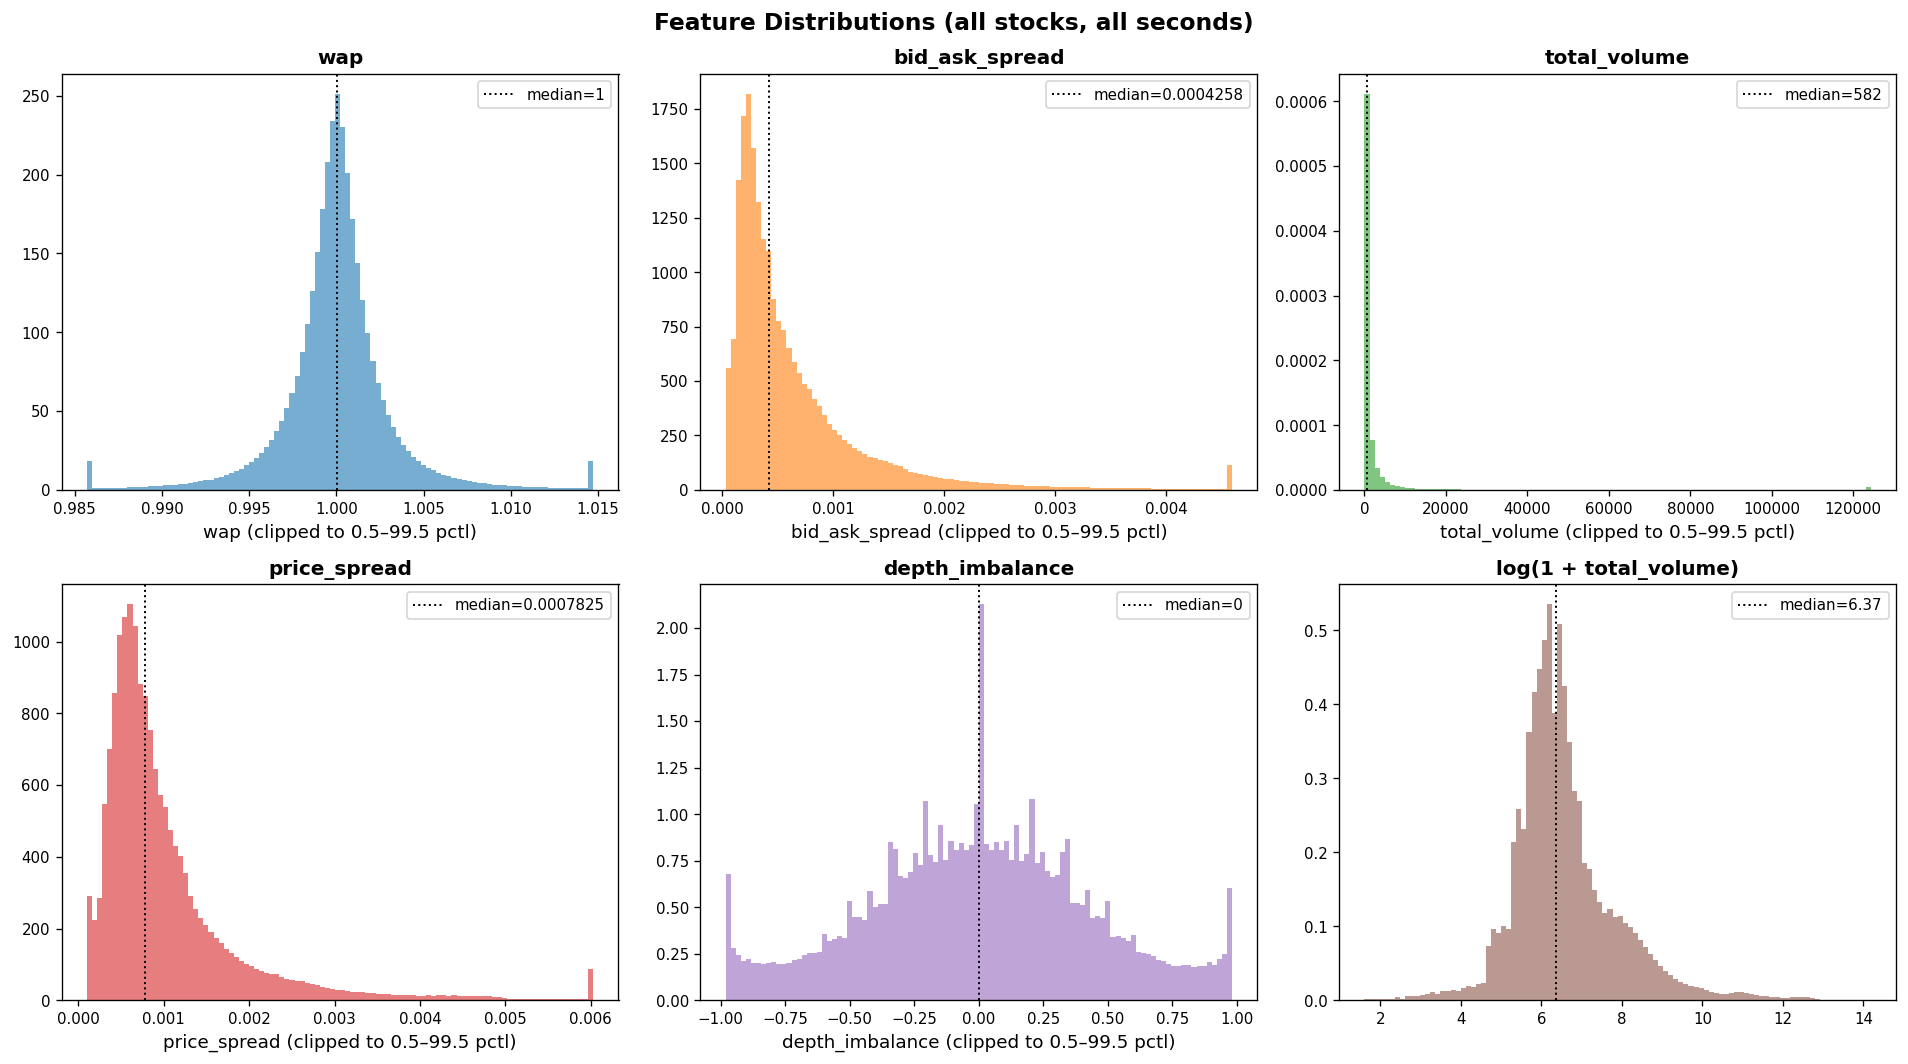

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.ravel()

for i, col in enumerate(FEATURE_COLS):
    ax = axes[i]
    vals = df[col].dropna()
    lo, hi = vals.quantile(0.005), vals.quantile(0.995)
    clipped = vals.clip(lo, hi)
    ax.hist(clipped, bins=100, density=True, alpha=0.6, color=f'C{i}')
    ax.axvline(vals.median(), color='black', ls=':', lw=1.2, label=f'median={vals.median():.4g}')
    ax.set_title(col, fontweight='bold')
    ax.set_xlabel(f'{col} (clipped to 0.5–99.5 pctl)')
    ax.legend()

# Log-transform of volume in last panel
ax = axes[5]
log_vol = np.log1p(df['total_volume'].dropna())
ax.hist(log_vol, bins=100, density=True, alpha=0.6, color='C5')
ax.axvline(log_vol.median(), color='black', ls=':', lw=1.2, label=f'median={log_vol.median():.2f}')
ax.set_title('log(1 + total_volume)', fontweight='bold')
ax.legend()

fig.suptitle('Feature Distributions (all stocks, all seconds)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'eda_feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Cross-Stock Variation

Different stocks have very different price levels, spreads, and volumes. This matters for noise floor estimation — a spread of 0.001 means something very different for a \$5 stock vs a \$500 stock.

In [ ]:
# Per-stock summary statistics
stock_stats = df.groupby('stock_id').agg(
    wap_mean         = ('wap', 'mean'),
    wap_std          = ('wap', 'std'),
    spread_mean      = ('bid_ask_spread', 'mean'),
    spread_median    = ('bid_ask_spread', 'median'),
    volume_mean      = ('total_volume', 'mean'),
    price_spread_mean= ('price_spread', 'mean'),
    vol_imbal_mean   = ('depth_imbalance', 'mean'),
    n_rows           = ('wap', 'size'),
).reset_index()

# Relative spread (spread / wap) — better cross-stock comparison
stock_stats['relative_spread'] = stock_stats['spread_mean'] / stock_stats['wap_mean']

print(f'{len(stock_stats)} stocks')
stock_stats.describe().T

112 stocks


,count,mean,std,min,25%,50%,75%,max
stock_id,112.0,6.243750e+01,37.292557,0.000000e+00,3.075000e+01,6.250000e+01,9.525000e+01,1.260000e+02
wap_mean,112.0,1.000007e+00,0.000060,9.998085e-01,9.999742e-01,1.000007e+00,1.000042e+00,1.000158e+00
wap_std,112.0,3.579237e-03,0.000900,1.770591e-03,3.083470e-03,3.482222e-03,3.991735e-03,7.936103e-03
spread_mean,112.0,6.633507e-04,0.000400,4.674157e-05,3.551814e-04,5.860607e-04,9.327239e-04,2.181012e-03
spread_median,112.0,5.166314e-04,0.000319,3.929861e-05,2.664621e-04,4.538666e-04,7.000661e-04,1.815100e-03
volume_mean,112.0,3.424116e+03,16611.748619,1.522612e+02,3.963824e+02,6.133789e+02,1.269022e+03,1.697433e+05
price_spread_mean,112.0,1.060500e-03,0.000534,1.078235e-04,6.772443e-04,9.554959e-04,1.312130e-03,3.615093e-03
vol_imbal_mean,112.0,-4.557745e-03,0.021491,-7.725613e-02,-1.595688e-02,-3.773217e-03,5.176766e-03,1.152577e-01
n_rows,112.0,2.297850e+06,1020.333809,2.289000e+06,2.298000e+06,2.298000e+06,2.298000e+06,2.298000e+06
relative_spread,112.0,6.633501e-04,0.000400,4.674154e-05,3.551989e-04,5.860594e-04,9.326491e-04,2.181430e-03


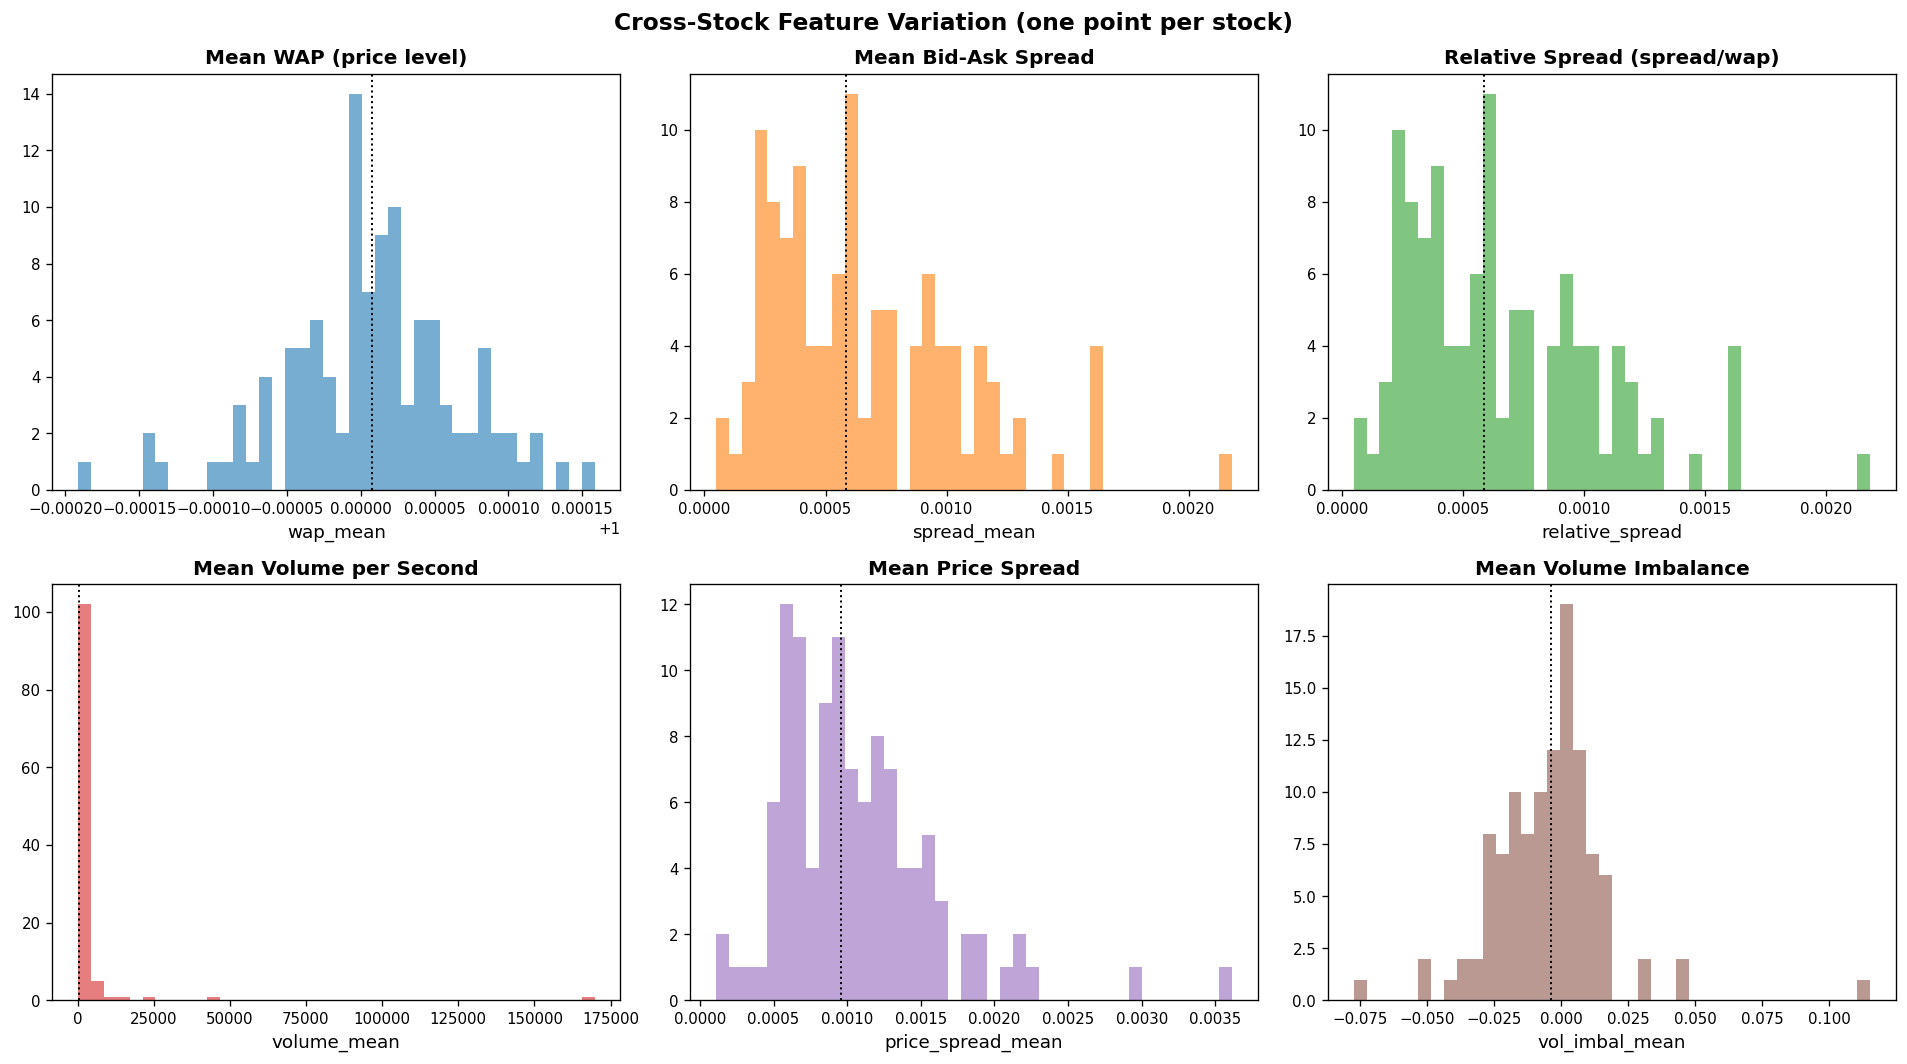

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

plot_cols = [
    ('wap_mean', 'Mean WAP (price level)', 'C0'),
    ('spread_mean', 'Mean Bid-Ask Spread', 'C1'),
    ('relative_spread', 'Relative Spread (spread/wap)', 'C2'),
    ('volume_mean', 'Mean Volume per Second', 'C3'),
    ('price_spread_mean', 'Mean Price Spread', 'C4'),
    ('vol_imbal_mean', 'Mean Volume Imbalance', 'C5'),
]

for ax, (col, title, color) in zip(axes.ravel(), plot_cols):
    vals = stock_stats[col].dropna()
    ax.hist(vals, bins=40, alpha=0.6, color=color)
    ax.axvline(vals.median(), color='black', ls=':', lw=1.2)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel(col)

fig.suptitle('Cross-Stock Feature Variation (one point per stock)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'eda_cross_stock_variation.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Target: Raw log(RV) Distribution

Compute RV from seconds 480–599 (the target window), **without** any floor, to see the true shape.

In [ ]:
# Compute RV per (stock_id, time_id) from target window
target_df = df[(df['seconds_in_bucket'] >= TARGET_START) &
               (df['seconds_in_bucket'] <  TARGET_END)].copy()
target_df.sort_values(['stock_id', 'time_id', 'seconds_in_bucket'], inplace=True)
target_df['log_wap'] = np.log(target_df['wap'].clip(lower=1e-12))
target_df['lr'] = target_df.groupby(['stock_id', 'time_id'])['log_wap'].diff().fillna(0.0)

rv_df = (target_df.groupby(['stock_id', 'time_id'])['lr']
         .apply(lambda x: np.sqrt((x**2).sum()))
         .reset_index(name='rv'))

n_total = len(rv_df)
n_zero  = (rv_df['rv'] == 0).sum()
n_pos   = n_total - n_zero

rv_df['log_rv'] = np.where(rv_df['rv'] > 0, np.log(rv_df['rv']), np.nan)

print(f'Total (stock, time_id) pairs: {n_total:,}')
print(f'  RV == 0 (no price movement): {n_zero:,} ({n_zero/n_total*100:.2f}%)')
print(f'  RV >  0: {n_pos:,} ({n_pos/n_total*100:.2f}%)')
print(f'\nlog(RV) stats (RV > 0 only):')
rv_df['log_rv'].dropna().describe(percentiles=[.01, .05, .25, .5, .75, .95, .99])

Total (stock, time_id) pairs: 428,932
  RV == 0 (no price movement): 9 (0.00%)
  RV >  0: 428,923 (100.00%)

log(RV) stats (RV > 0 only):


count    428923.000000
mean         -6.614025
std           0.711694
min         -14.136505
1%           -8.247079
5%           -7.726640
25%          -7.090997
50%          -6.638481
75%          -6.150777
95%          -5.407221
99%          -4.906194
max          -3.142111
Name: log_rv, dtype: float64

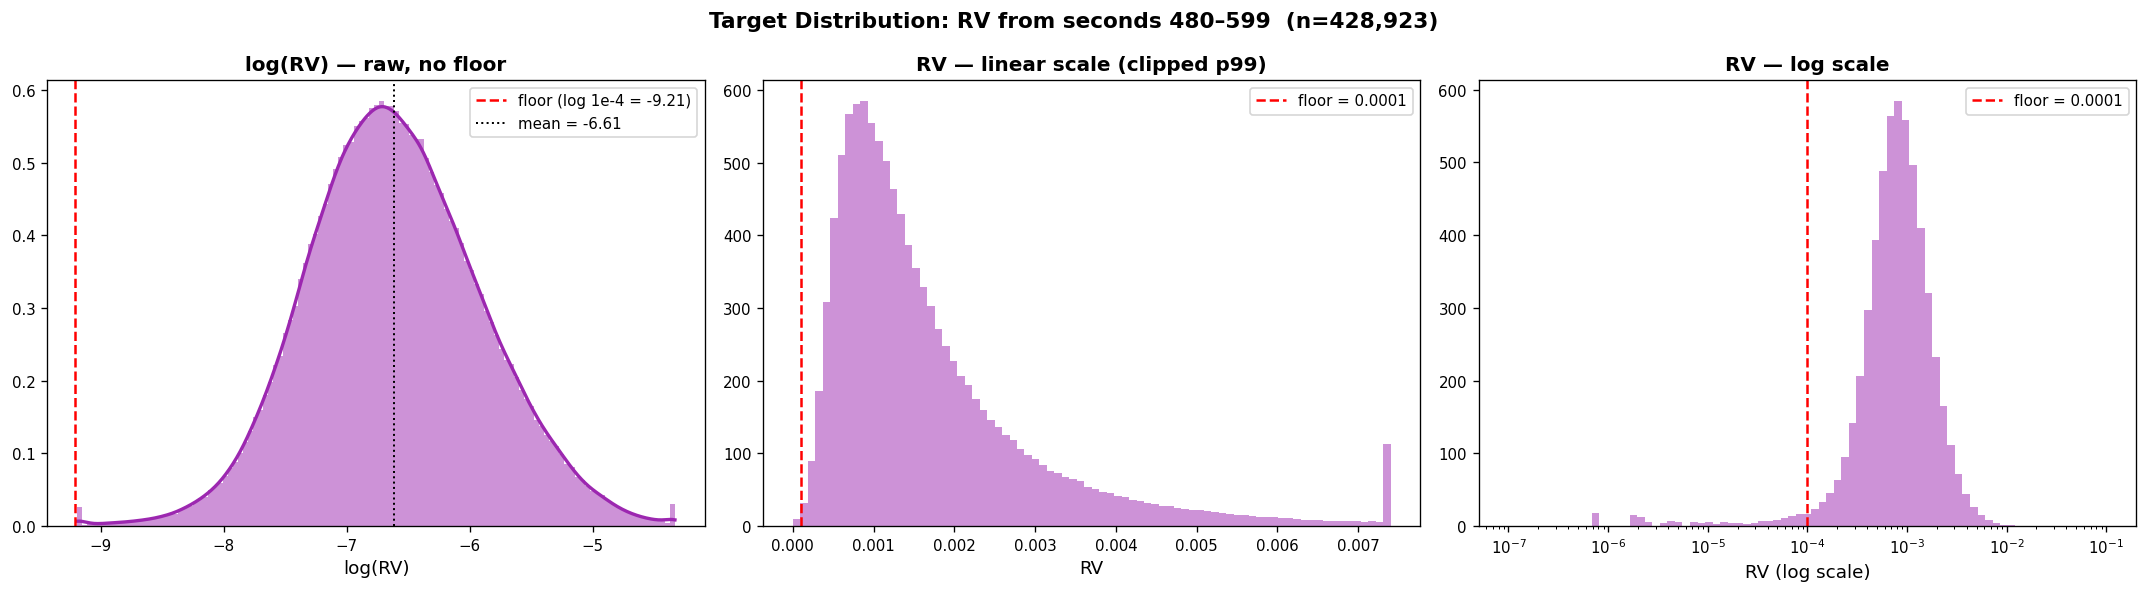


0.1% of samples fall below the RV floor (log = -9.21)


In [ ]:
log_rv = rv_df['log_rv'].dropna()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. log(RV) histogram + KDE
ax = axes[0]
lo, hi = log_rv.quantile(0.001), log_rv.quantile(0.999)
bins = np.linspace(lo, hi, 120)
ax.hist(log_rv.clip(lo, hi), bins=bins, density=True, alpha=0.5, color='#9C27B0')
if len(log_rv) > 200:
    kde = gaussian_kde(log_rv.clip(lo, hi), bw_method=0.1)
    xk = np.linspace(lo, hi, 500)
    ax.plot(xk, kde(xk), color='#9C27B0', lw=2)
ax.axvline(LOG_RV_FLOOR, color='red', ls='--', lw=1.5, label=f'floor (log 1e-4 = {LOG_RV_FLOOR:.2f})')
ax.axvline(log_rv.mean(), color='black', ls=':', lw=1.2, label=f'mean = {log_rv.mean():.2f}')
ax.set_title('log(RV) — raw, no floor', fontweight='bold')
ax.set_xlabel('log(RV)')
ax.legend()

# 2. RV linear scale (clipped at p99)
ax = axes[1]
rv_vals = np.exp(log_rv)
rv_p99 = np.percentile(rv_vals, 99)
ax.hist(np.minimum(rv_vals, rv_p99), bins=80, density=True, alpha=0.5, color='#9C27B0')
ax.axvline(RV_FLOOR, color='red', ls='--', lw=1.5, label=f'floor = {RV_FLOOR}')
ax.set_title('RV — linear scale (clipped p99)', fontweight='bold')
ax.set_xlabel('RV')
ax.legend()

# 3. RV log scale
ax = axes[2]
rv_pos = rv_vals[rv_vals > 0]
log_bins = np.logspace(np.floor(np.log10(rv_pos.min())), np.ceil(np.log10(rv_pos.max())), 80)
ax.hist(rv_pos, bins=log_bins, density=True, alpha=0.5, color='#9C27B0')
ax.axvline(RV_FLOOR, color='red', ls='--', lw=1.5, label=f'floor = {RV_FLOOR}')
ax.set_xscale('log')
ax.set_title('RV — log scale', fontweight='bold')
ax.set_xlabel('RV (log scale)')
ax.legend()

fig.suptitle(f'Target Distribution: RV from seconds {TARGET_START}–{TARGET_END-1}  (n={n_pos:,})',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'eda_target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

below_floor = (log_rv < LOG_RV_FLOOR).mean() * 100
print(f'\n{below_floor:.1f}% of samples fall below the RV floor (log = {LOG_RV_FLOOR:.2f})')

## 5. Per-Stock Target Variation

Some stocks are inherently more volatile — their RV is always above the noise floor, while others frequently sit at the floor.

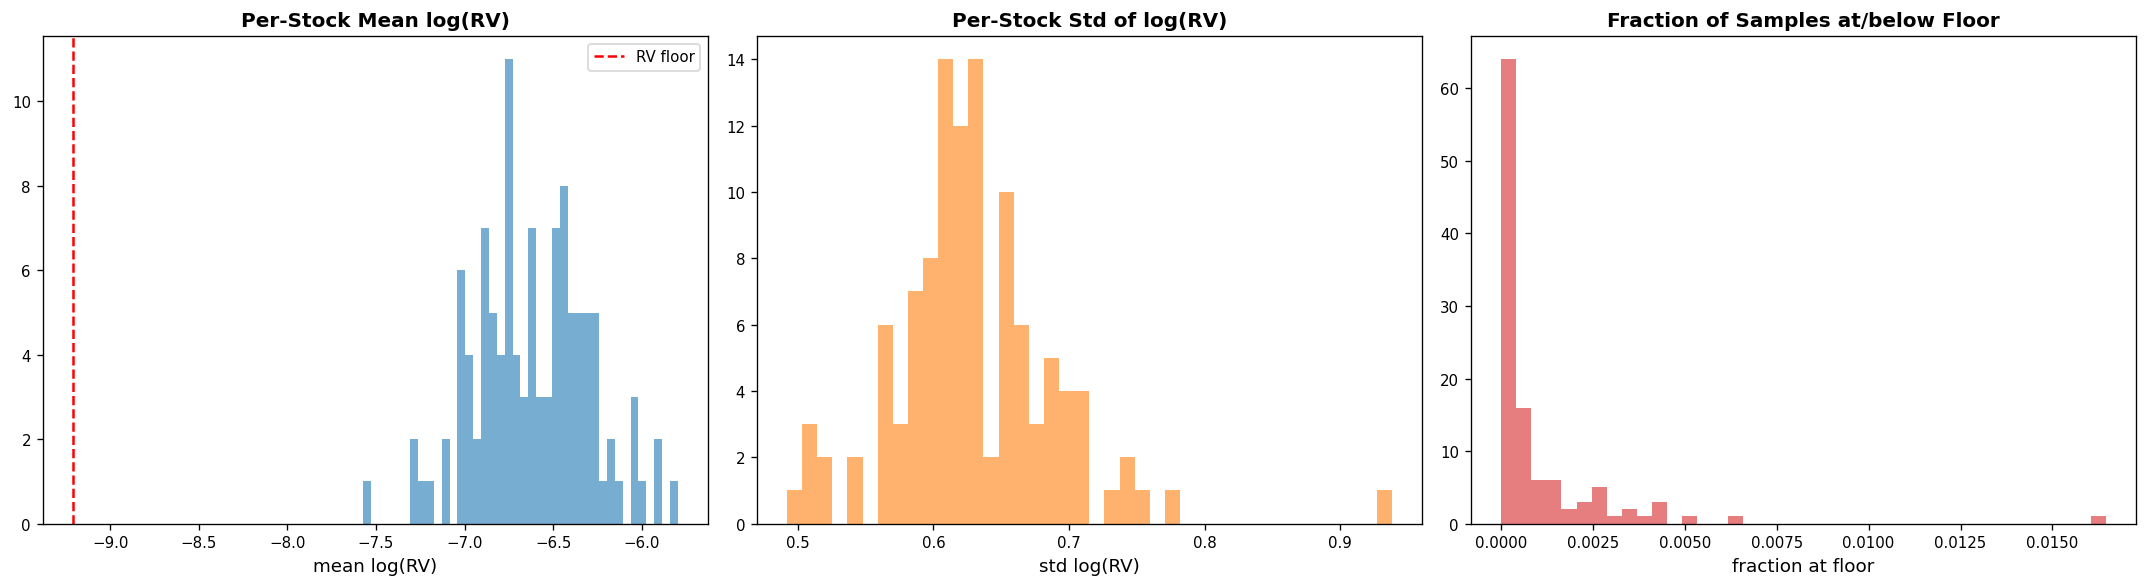

Stocks where >50% of samples are at floor: 0
Stocks where >90% of samples are at floor: 0


In [ ]:
stock_rv = rv_df.groupby('stock_id')['log_rv'].agg(['mean', 'std', 'count']).reset_index()
stock_rv.columns = ['stock_id', 'log_rv_mean', 'log_rv_std', 'n_samples']

# Fraction of samples at/below floor per stock
floor_frac = (rv_df.groupby('stock_id')
              .apply(lambda g: (g['log_rv'].fillna(-999) <= LOG_RV_FLOOR).mean())
              .reset_index(name='frac_at_floor'))
stock_rv = stock_rv.merge(floor_frac, on='stock_id')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

ax = axes[0]
ax.hist(stock_rv['log_rv_mean'].dropna(), bins=40, alpha=0.6, color='C0')
ax.axvline(LOG_RV_FLOOR, color='red', ls='--', lw=1.5, label='RV floor')
ax.set_title('Per-Stock Mean log(RV)', fontweight='bold')
ax.set_xlabel('mean log(RV)')
ax.legend()

ax = axes[1]
ax.hist(stock_rv['log_rv_std'].dropna(), bins=40, alpha=0.6, color='C1')
ax.set_title('Per-Stock Std of log(RV)', fontweight='bold')
ax.set_xlabel('std log(RV)')

ax = axes[2]
ax.hist(stock_rv['frac_at_floor'], bins=40, alpha=0.6, color='C3')
ax.set_title('Fraction of Samples at/below Floor', fontweight='bold')
ax.set_xlabel('fraction at floor')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'eda_per_stock_target.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Stocks where >50% of samples are at floor: {(stock_rv["frac_at_floor"] > 0.5).sum()}')
print(f'Stocks where >90% of samples are at floor: {(stock_rv["frac_at_floor"] > 0.9).sum()}')

## 6. Stock Interaction Tests

Four statistical tests adapted from `stock_interaction_test.py`: cross-stock RV correlation, Granger causality, permutation baseline, and same-time vs lagged correlation.

These tests quantify whether cross-stock signals carry genuine information for forecasting.

In [ ]:
from scipy import stats
from scipy.stats import f as f_dist
import json as _json

# ── Stock interaction config ──
EPS           = 1e-8
LOG_RV_FLOOR  = -18.0
GRANGER_LAGS  = 3
N_STOCK_PAIRS = 200
GRANGER_ALPHA = 0.05
N_PERMUTATIONS = 100


In [ ]:
# Build wide panel from rv_df computed in section 4
# index: time_id, columns: stock_id, values: log_rv
live = (rv_df['log_rv'].notna()) & (rv_df['log_rv'] > LOG_RV_FLOOR)
panel = (rv_df[live]
         .pivot(index='time_id', columns='stock_id', values='log_rv')
         .sort_index())
print(f'Panel shape: {panel.shape[0]} time_ids x {panel.shape[1]} stocks')
print(f'Sparsity: {panel.isna().mean().mean()*100:.1f}% missing')


Panel shape: 3830 time_ids x 112 stocks
Sparsity: 0.0% missing


In [ ]:
def test_correlation(panel):
    print('\n' + '='*55)
    print('Test 1: Cross-Stock RV Correlation')
    print('='*55)

    obs_count   = panel.notna().sum()
    good_stocks = obs_count[obs_count >= panel.shape[0] * 0.5].index
    sub = panel[good_stocks].dropna(how='all')

    corr_matrix = sub.corr(method='pearson')
    n = len(corr_matrix)
    upper = corr_matrix.values[np.triu_indices(n, k=1)]
    upper = upper[~np.isnan(upper)]

    print(f'Stocks analysed: {n}')
    print(f'Stock pairs    : {len(upper):,}')
    print(f'\nPairwise log(RV) correlation:')
    print(f'  Mean        : {upper.mean():.4f}')
    print(f'  Median      : {np.median(upper):.4f}')
    print(f'  Std         : {upper.std():.4f}')
    print(f'  % positive  : {(upper > 0).mean()*100:.1f}%')
    print(f'  % > 0.3     : {(upper > 0.3).mean()*100:.1f}%  (moderate correlation)')
    print(f'  % > 0.5     : {(upper > 0.5).mean()*100:.1f}%  (strong correlation)')

    if upper.mean() > 0.3:
        print('\n  FINDING: Strong average cross-stock RV correlation.')
        print('  Stocks move together — cross-stock signals should help forecasting.')
    elif upper.mean() > 0.1:
        print('\n  FINDING: Moderate average cross-stock RV correlation.')
        print('  Some co-movement — cross-stock signals may help on active days.')
    else:
        print('\n  FINDING: Weak average cross-stock RV correlation.')
        print('  Stocks are largely independent — cross-stock signals unlikely to help.')

    corr_matrix.to_csv(OUTPUT_DIR / 'rv_correlation_matrix.csv')
    print(f'\n  Correlation matrix saved -> {OUTPUT_DIR / "rv_correlation_matrix.csv"}')

    return {
        'mean_corr'   : float(upper.mean()),
        'median_corr' : float(np.median(upper)),
        'pct_positive': float((upper > 0).mean()),
        'pct_gt_03'   : float((upper > 0.3).mean()),
        'pct_gt_05'   : float((upper > 0.5).mean()),
        'n_stocks'    : n,
        'n_pairs'     : len(upper),
    }

si_corr = test_correlation(panel)



Test 1: Cross-Stock RV Correlation
Stocks analysed: 112
Stock pairs    : 6,216

Pairwise log(RV) correlation:
  Mean        : 0.6745
  Median      : 0.6850
  Std         : 0.0833
  % positive  : 100.0%
  % > 0.3     : 100.0%  (moderate correlation)
  % > 0.5     : 97.0%  (strong correlation)

  FINDING: Strong average cross-stock RV correlation.
  Stocks move together — cross-stock signals should help forecasting.

  Correlation matrix saved -> c:\Users\ngdo0466\OneDrive - The University of Sydney (Students)\Final\models\rv_correlation_matrix.csv


In [ ]:
def granger_test_pair(y, x, lags=1):
    df_g = pd.DataFrame({'y': y, 'x': x}).dropna()
    if len(df_g) < lags + 10:
        return np.nan
    y_arr, x_arr = df_g['y'].values, df_g['x'].values
    n = len(y_arr) - lags
    Y     = y_arr[lags:]
    Y_lag = y_arr[:-lags].reshape(-1, 1)
    X_lag = x_arr[:-lags].reshape(-1, 1)
    ones  = np.ones((n, 1))
    Z_r    = np.hstack([ones, Y_lag])
    beta_r = np.linalg.lstsq(Z_r, Y, rcond=None)[0]
    rss_r  = np.sum((Y - Z_r @ beta_r) ** 2)
    Z_u    = np.hstack([ones, Y_lag, X_lag])
    beta_u = np.linalg.lstsq(Z_u, Y, rcond=None)[0]
    rss_u  = np.sum((Y - Z_u @ beta_u) ** 2)
    q, k = lags, Z_u.shape[1]
    df2 = n - k
    if df2 <= 0 or rss_u <= 0:
        return np.nan
    f_stat = ((rss_r - rss_u) / q) / (rss_u / df2)
    return float(1 - f_dist.cdf(f_stat, q, df2))


def test_granger(panel):
    print('\n' + '='*55)
    print('Test 2: Granger Causality')
    print(f'  Lags: {GRANGER_LAGS} | Pairs tested: {N_STOCK_PAIRS} | a={GRANGER_ALPHA}')
    print('='*55)

    stocks = panel.columns.tolist()
    if len(stocks) < 2:
        print('Not enough stocks for Granger test.')
        return {}

    rng = np.random.default_rng(42)
    pairs = [(int(rng.choice(len(stocks))), int(rng.choice(len(stocks))))
             for _ in range(N_STOCK_PAIRS * 3)]
    pairs = [(a, b) for a, b in pairs if a != b][:N_STOCK_PAIRS]

    p_values = []
    for a_idx, b_idx in pairs:
        p = granger_test_pair(panel[stocks[b_idx]].values,
                              panel[stocks[a_idx]].values, lags=GRANGER_LAGS)
        if not np.isnan(p):
            p_values.append(p)

    p_values = np.array(p_values)
    pct_significant = float((p_values < GRANGER_ALPHA).mean())

    print(f'Valid pairs tested : {len(p_values)}')
    print(f'Significant pairs  : {(p_values < GRANGER_ALPHA).sum()} ({pct_significant*100:.1f}%)')
    print(f'Expected by chance : {GRANGER_ALPHA*100:.1f}%')
    print(f'Mean p-value       : {p_values.mean():.4f}')
    print(f'Median p-value     : {np.median(p_values):.4f}')

    binom_result = stats.binomtest(
        int((p_values < GRANGER_ALPHA).sum()), len(p_values),
        GRANGER_ALPHA, alternative='greater'
    )
    print(f'\nBinomial test p-value: {binom_result.pvalue:.4f}')
    if binom_result.pvalue < 0.05:
        print('  FINDING: Significantly more Granger-causal pairs than chance.')
        print('  Stock interactions are statistically informative for forecasting.')
    else:
        print('  FINDING: No significant excess of Granger-causal pairs.')
        print('  Cross-stock signals may not add reliable forecasting value.')

    return {
        'n_pairs_tested'         : len(p_values),
        'pct_significant'        : pct_significant,
        'expected_by_chance'     : GRANGER_ALPHA,
        'mean_pvalue'            : float(p_values.mean()),
        'median_pvalue'          : float(np.median(p_values)),
        'binom_pvalue'           : float(binom_result.pvalue),
        'interaction_significant': bool(binom_result.pvalue < 0.05),
    }

si_granger = test_granger(panel)



Test 2: Granger Causality
  Lags: 3 | Pairs tested: 200 | a=0.05
Valid pairs tested : 200
Significant pairs  : 1 (0.5%)
Expected by chance : 5.0%
Mean p-value       : 0.8115
Median p-value     : 0.9294

Binomial test p-value: 1.0000
  FINDING: No significant excess of Granger-causal pairs.
  Cross-stock signals may not add reliable forecasting value.


In [ ]:
def test_permutation(panel):
    print('\n' + '='*55)
    print('Test 3: Permutation Baseline')
    print(f'  Shuffles: {N_PERMUTATIONS}')
    print('='*55)

    obs_count   = panel.notna().sum()
    good_stocks = obs_count[obs_count >= panel.shape[0] * 0.5].index
    sub         = panel[good_stocks].dropna(how='all')

    corr_real  = sub.corr().values
    n          = len(corr_real)
    upper_idx  = np.triu_indices(n, k=1)
    real_upper = corr_real[upper_idx]
    real_upper = real_upper[~np.isnan(real_upper)]
    real_mean  = float(real_upper.mean())

    rng        = np.random.default_rng(42)
    perm_means = []
    for _ in range(N_PERMUTATIONS):
        shuffled = sub.copy()
        for tid in shuffled.index:
            row   = shuffled.loc[tid].values.copy()
            valid = ~np.isnan(row)
            row[valid] = rng.permutation(row[valid])
            shuffled.loc[tid] = row
        corr_perm  = shuffled.corr().values
        perm_upper = corr_perm[upper_idx]
        perm_upper = perm_upper[~np.isnan(perm_upper)]
        perm_means.append(float(perm_upper.mean()))

    perm_means = np.array(perm_means)
    null_mean  = float(perm_means.mean())
    null_std   = float(perm_means.std())
    z_score    = (real_mean - null_mean) / (null_std + 1e-10)
    p_value    = float(stats.norm.sf(z_score))

    print(f'Real mean correlation : {real_mean:.4f}')
    print(f'Null mean correlation : {null_mean:.4f}  (+/-{null_std:.4f})')
    print(f'Excess correlation    : {real_mean - null_mean:.4f}')
    print(f'Z-score               : {z_score:.2f}')
    print(f'P-value (one-sided)   : {p_value:.4f}')

    if p_value < 0.05:
        print(f'\n  FINDING: Real correlation ({real_mean:.3f}) significantly exceeds null ({null_mean:.3f}).')
        print(f'  Stock spatial structure is genuine.')
    else:
        print(f'\n  FINDING: Real correlation not significantly above null.')
        print(f'  Observed co-movement may be a statistical artifact.')

    return {
        'real_mean_corr'     : real_mean,
        'null_mean_corr'     : null_mean,
        'null_std_corr'      : null_std,
        'excess_corr'        : real_mean - null_mean,
        'z_score'            : float(z_score),
        'p_value'            : p_value,
        'n_permutations'     : N_PERMUTATIONS,
        'spatial_significant': bool(p_value < 0.05),
    }

si_perm = test_permutation(panel)



Test 3: Permutation Baseline
  Shuffles: 100
Real mean correlation : 0.6745
Null mean correlation : 0.5226  (+/-0.0000)
Excess correlation    : 0.1519
Z-score               : 10428.42
P-value (one-sided)   : 0.0000

  FINDING: Real correlation (0.674) significantly exceeds null (0.523).
  Stock spatial structure is genuine.


In [ ]:
def test_lead_lag(panel):
    print('\n' + '='*55)
    print('Test 4: Same-Time vs Lagged Correlation')
    print('='*55)

    obs_count   = panel.notna().sum()
    good_stocks = obs_count[obs_count >= panel.shape[0] * 0.7].index
    sub         = panel[good_stocks].dropna()

    if len(sub) < 10:
        print('Not enough complete rows for lead-lag test.')
        return {}

    n         = len(sub.columns)
    upper_idx = np.triu_indices(n, k=1)
    corr_same = sub.corr().values[upper_idx]
    corr_same = corr_same[~np.isnan(corr_same)]

    sub_t  = sub.iloc[:-1].values
    sub_t1 = sub.iloc[1:].values
    lag_corrs = []
    for i in range(n):
        for j in range(i+1, n):
            mask = ~(np.isnan(sub_t[:, i]) | np.isnan(sub_t1[:, j]))
            if mask.sum() < 10:
                continue
            r, _ = stats.pearsonr(sub_t[mask, i], sub_t1[mask, j])
            lag_corrs.append(r)
    lag_corrs = np.array(lag_corrs)

    print(f'Same-time correlation : mean={corr_same.mean():.4f}  std={corr_same.std():.4f}')
    print(f'Lagged correlation    : mean={lag_corrs.mean():.4f}  std={lag_corrs.std():.4f}')
    print(f'Lag decay ratio       : {lag_corrs.mean()/max(corr_same.mean(), EPS):.3f}')
    pct_lag_sig = float((np.abs(lag_corrs) > 0.1).mean())
    print(f'Pairs with |lag corr| > 0.1: {pct_lag_sig*100:.1f}%')

    if lag_corrs.mean() > 0.05:
        print(f'\n  FINDING: Meaningful lagged correlation ({lag_corrs.mean():.3f}).')
        print(f'  Stock A past RV predicts stock B future RV.')
        print(f'  Cross-stock signals have genuine PREDICTIVE value.')
    else:
        print(f'\n  FINDING: Weak lagged correlation ({lag_corrs.mean():.3f}).')
        print(f'  Cross-stock co-movement is mostly contemporaneous.')

    return {
        'same_time_mean_corr': float(corr_same.mean()),
        'lagged_mean_corr'   : float(lag_corrs.mean()),
        'lag_decay_ratio'    : float(lag_corrs.mean() / max(corr_same.mean(), EPS)),
        'pct_lag_significant': pct_lag_sig,
        'predictive_value'   : bool(lag_corrs.mean() > 0.05),
    }

si_leadlag = test_lead_lag(panel)



Test 4: Same-Time vs Lagged Correlation
Same-time correlation : mean=0.6713  std=0.0836
Lagged correlation    : mean=-0.0112  std=0.0127
Lag decay ratio       : -0.017
Pairs with |lag corr| > 0.1: 0.0%

  FINDING: Weak lagged correlation (-0.011).
  Cross-stock co-movement is mostly contemporaneous.


In [ ]:
# ── Stock interaction summary ──
si_results = {
    'correlation': si_corr,
    'granger'    : si_granger,
    'permutation': si_perm,
    'lead_lag'   : si_leadlag,
}

c, g, p, l = si_corr, si_granger, si_perm, si_leadlag
print('\n' + '='*55)
print('STOCK INTERACTION SUMMARY')
print('='*55)
print(f'{"Test":<30} {"Finding":<15} {"Key Stat"}')
print('-' * 55)
print(f'{"1. Cross-stock correlation":<30} '
      f'{"STRONG" if c["mean_corr"] > 0.3 else "WEAK":<15} '
      f'mean_corr={c["mean_corr"]:.3f}')
print(f'{"2. Granger causality":<30} '
      f'{"SIGNIFICANT" if g.get("interaction_significant") else "NOT SIG":<15} '
      f'pct_sig={g.get("pct_significant", 0)*100:.1f}%')
print(f'{"3. Permutation test":<30} '
      f'{"REAL" if p.get("spatial_significant") else "RANDOM":<15} '
      f'z={p.get("z_score", 0):.2f}')
print(f'{"4. Lagged correlation":<30} '
      f'{"PREDICTIVE" if l.get("predictive_value") else "CONTEMPOR.":<15} '
      f'lag_corr={l.get("lagged_mean_corr", 0):.3f}')

n_positive = sum([
    c['mean_corr'] > 0.3,
    g.get('interaction_significant', False),
    p.get('spatial_significant', False),
    l.get('predictive_value', False),
])
print(f'\nOverall: {n_positive}/4 tests support cross-stock interactions')
if n_positive >= 3:
    print('VERDICT: Strong evidence — cross-stock signals are worth modelling.')
elif n_positive >= 2:
    print('VERDICT: Moderate evidence — cross-stock signals exist but are weak.')
else:
    print('VERDICT: Weak evidence — stocks behave mostly independently.')

out_path = OUTPUT_DIR / 'stock_interaction_results.json'
with open(out_path, 'w') as _f:
    _json.dump(si_results, _f, indent=2)
print(f'\nResults saved -> {out_path}')



STOCK INTERACTION SUMMARY
Test                           Finding         Key Stat
-------------------------------------------------------
1. Cross-stock correlation     STRONG          mean_corr=0.674
2. Granger causality           NOT SIG         pct_sig=0.5%
3. Permutation test            REAL            z=10428.42
4. Lagged correlation          CONTEMPOR.      lag_corr=-0.011

Overall: 2/4 tests support cross-stock interactions
VERDICT: Moderate evidence — cross-stock signals exist but are weak.

Results saved -> c:\Users\ngdo0466\OneDrive - The University of Sydney (Students)\Final\models\stock_interaction_results.json


## 7. Intraday Patterns (Seconds-Level)

How do features evolve across the 600-second window? Look for U-shapes in volatility/spread (common in intraday data) and regime changes at the target boundary (second 480).

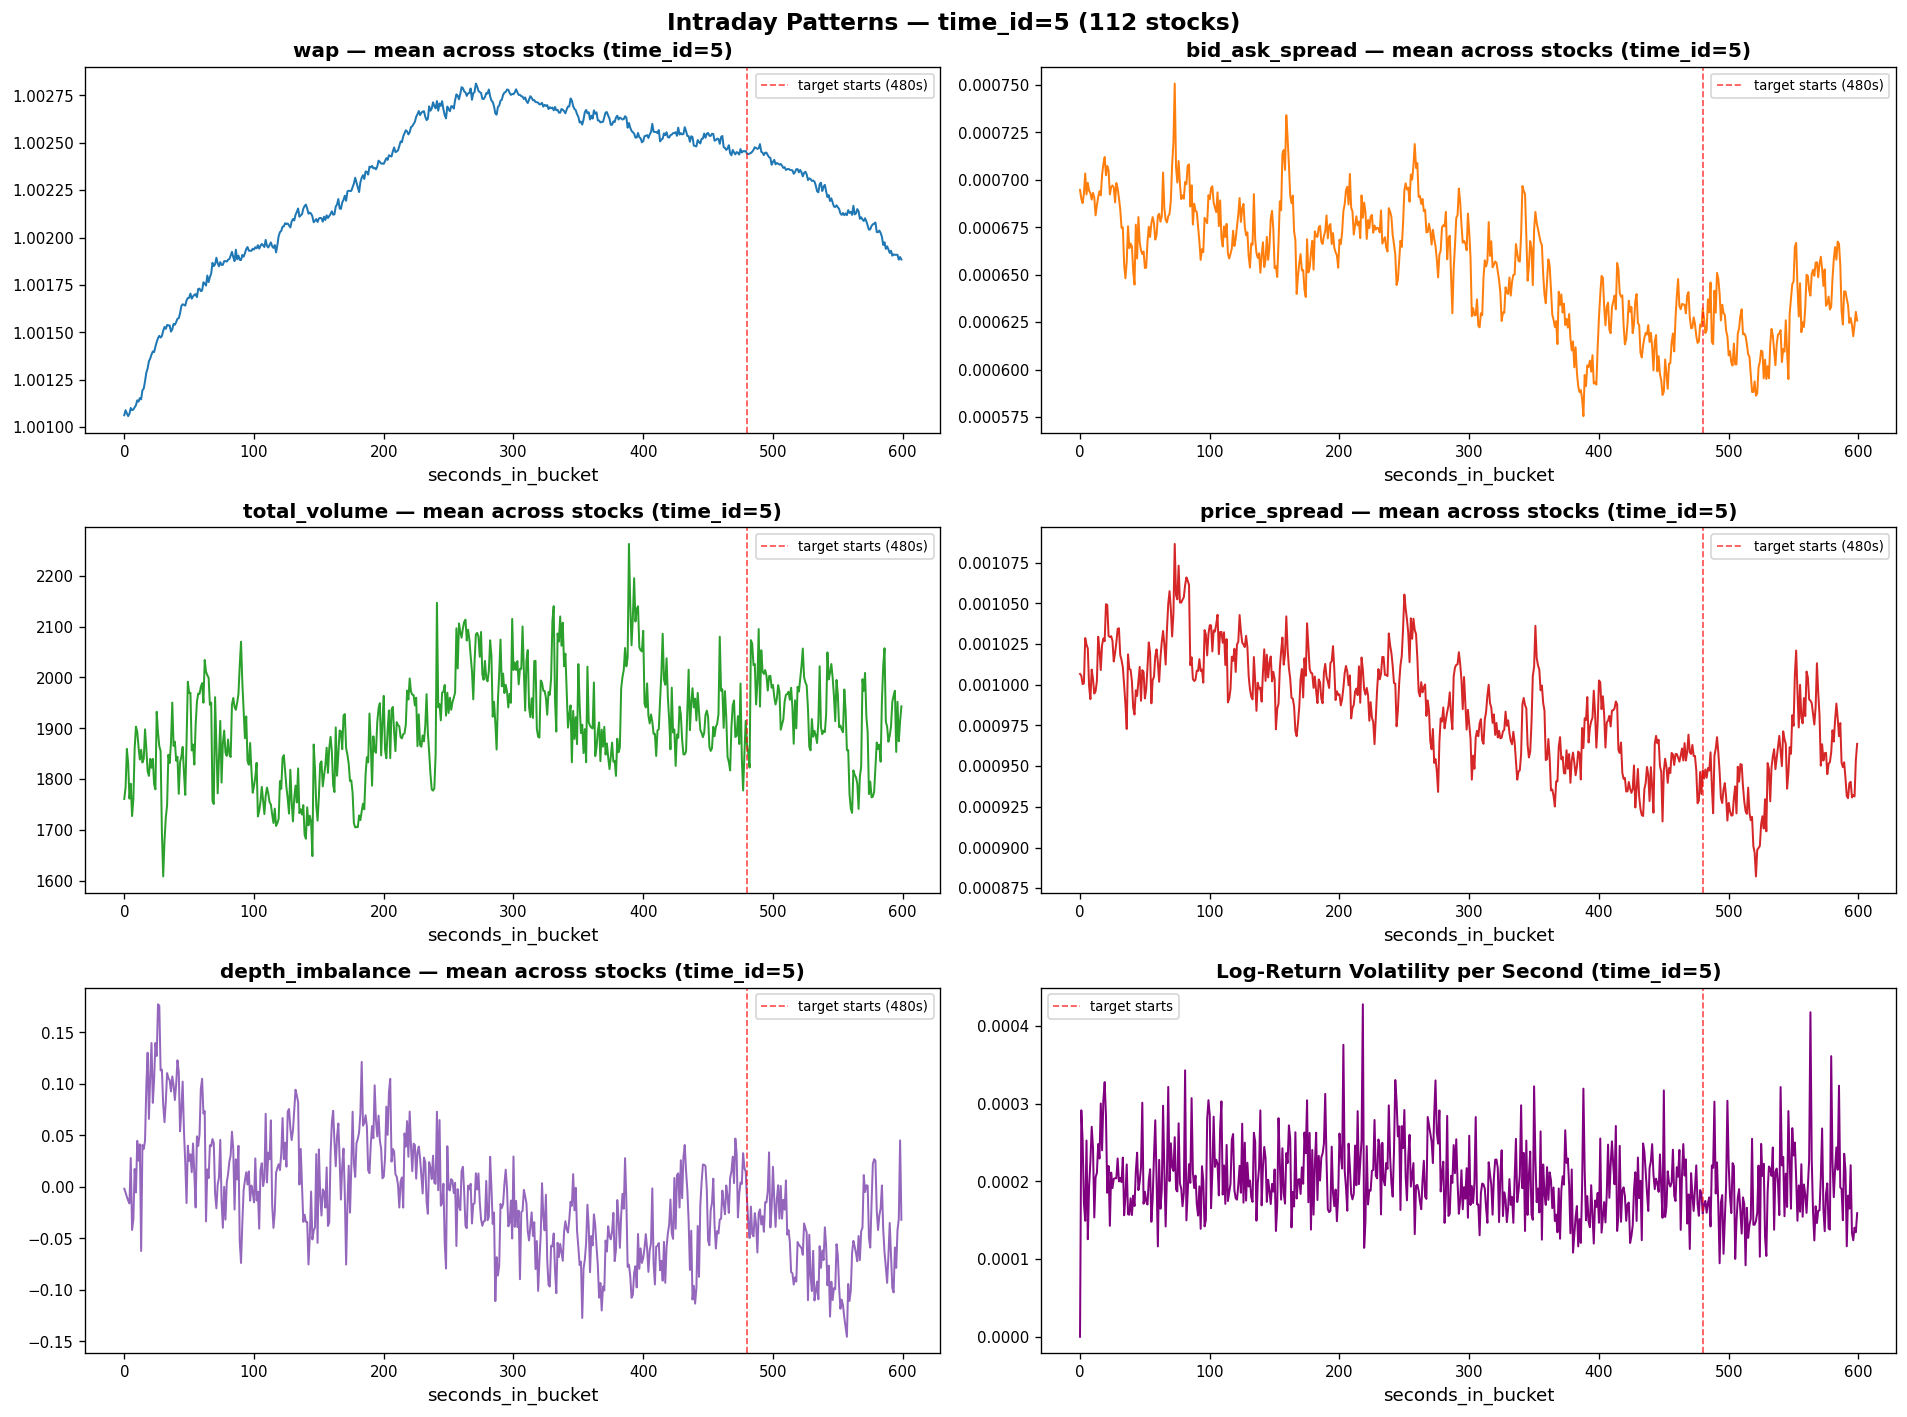

In [ ]:
# Pick one time_id for demonstration
demo_tid = sorted(df['time_id'].unique())[0]
sub = df[df['time_id'] == demo_tid].copy()

# Per-second aggregates across all stocks for that time_id
sec_agg = sub.groupby('seconds_in_bucket')[FEATURE_COLS].agg(['mean', 'std']).reset_index()
sec_agg.columns = ['_'.join(c).strip('_') for c in sec_agg.columns]

fig, axes = plt.subplots(3, 2, figsize=(16, 12))
axes = axes.ravel()

for i, col in enumerate(FEATURE_COLS):
    ax = axes[i]
    x = sec_agg['seconds_in_bucket']
    y = sec_agg[f'{col}_mean']
    ax.plot(x, y, color=f'C{i}', lw=1.2)
    ax.axvline(TARGET_START, color='red', ls='--', lw=1, alpha=0.7, label='target starts (480s)')
    ax.set_title(f'{col} — mean across stocks (time_id={demo_tid})', fontweight='bold')
    ax.set_xlabel('seconds_in_bucket')
    ax.legend(fontsize=8)

# Log-return volatility per second
ax = axes[5]
sub.sort_values(['stock_id', 'seconds_in_bucket'], inplace=True)
sub['log_wap'] = np.log(sub['wap'].clip(lower=1e-12))
sub['lr'] = sub.groupby('stock_id')['log_wap'].diff().fillna(0.0)
lr_vol = sub.groupby('seconds_in_bucket')['lr'].std().reset_index(name='lr_std')
ax.plot(lr_vol['seconds_in_bucket'], lr_vol['lr_std'], color='purple', lw=1.2)
ax.axvline(TARGET_START, color='red', ls='--', lw=1, alpha=0.7, label='target starts')
ax.set_title(f'Log-Return Volatility per Second (time_id={demo_tid})', fontweight='bold')
ax.set_xlabel('seconds_in_bucket')
ax.legend(fontsize=8)

fig.suptitle(f'Intraday Patterns — time_id={demo_tid} ({sub["stock_id"].nunique()} stocks)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'eda_intraday_patterns.png', dpi=150, bbox_inches='tight')
plt.show()

## 18. Summary & Key Findings

In [ ]:
print('=' * 70)
print('EDA SUMMARY')
print('=' * 70)
print(f'Data shape:      {df.shape}')
print(f'Stocks:          {df["stock_id"].nunique()}')
print(f'Time IDs:        {df["time_id"].nunique()}')
print(f'Seconds/sample:  {df.groupby(["stock_id", "time_id"]).size().median():.0f}')
print()
print('TARGET (log RV, seconds 480-599):')
print(f'  n total:       {n_total:,}')
print(f'  n zero RV:     {n_zero:,} ({n_zero/n_total*100:.1f}%)')
print(f'  mean log(RV):  {log_rv.mean():.3f}')
print(f'  std log(RV):   {log_rv.std():.3f}')
print(f'  below floor:   {below_floor:.1f}%')
print()
print('STOCK INTERACTION RESULTS:')
print(f'  Cross-stock correlation: mean={si_corr["mean_corr"]:.3f}')
print(f'  Granger significant:     {si_granger.get("interaction_significant", False)}')
print(f'  Permutation p-value:     {si_perm.get("p_value", float("nan")):.4f}')
print(f'  Lagged correlation:      {si_leadlag.get("lagged_mean_corr", 0):.3f}')
print()
print('IMPLICATIONS FOR MODELLING:')
print('  1. Input-window RV is likely the strongest predictor (autoregressive signal)')
print('  2. Relative spread (spread/wap) is a better cross-stock feature than raw spread')
print('  3. See stock_interaction_results.json for full cross-stock test results')
print('=' * 70)
